<a href="https://colab.research.google.com/github/Daniphantom99/AW/blob/main/TAU_DS_Activity_wall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 16.3 MB/s eta 0:00:00


In [4]:
#Database con propiedades fisicoquimicas KNIME.
database = pd.read_csv("/content/Tau_DS_KNIME.csv")
print(database.shape)

(5211, 19)


In [5]:
#Conocer las columnas
database.columns[:60]

Index(['Molecule ChEMBL ID', 'Molecule Name', 'Smiles', 'Standard Type',
       'Standard Relation', 'Standard Value', 'Standard Units', 'Comment',
       'Molecule Max Phase', 'Activity µM', 'canonical_smiles', 'NEW_SMILES',
       'SMILES_new', 'SlogP', 'TPSA', 'ExactMW', 'NumRotatableBonds', 'NumHBD',
       'NumHBA'],
      dtype='object')

# Analisis de propiedades **fisicoquimicas** **texto en negrita**

/tmp/ipykernel_1720/241886567.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=database, x="NumHBD", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_1720/241886567.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=database, x="NumHBA", ax=axes[1], palette="Creams_d" if "Creams_d" in dir(sns.color_palette) else "Oranges_d")
/tmp/ipykernel_1720/241886567.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=database, x="NumRotatableBonds", ax=axes[2], palette="Greens_d")


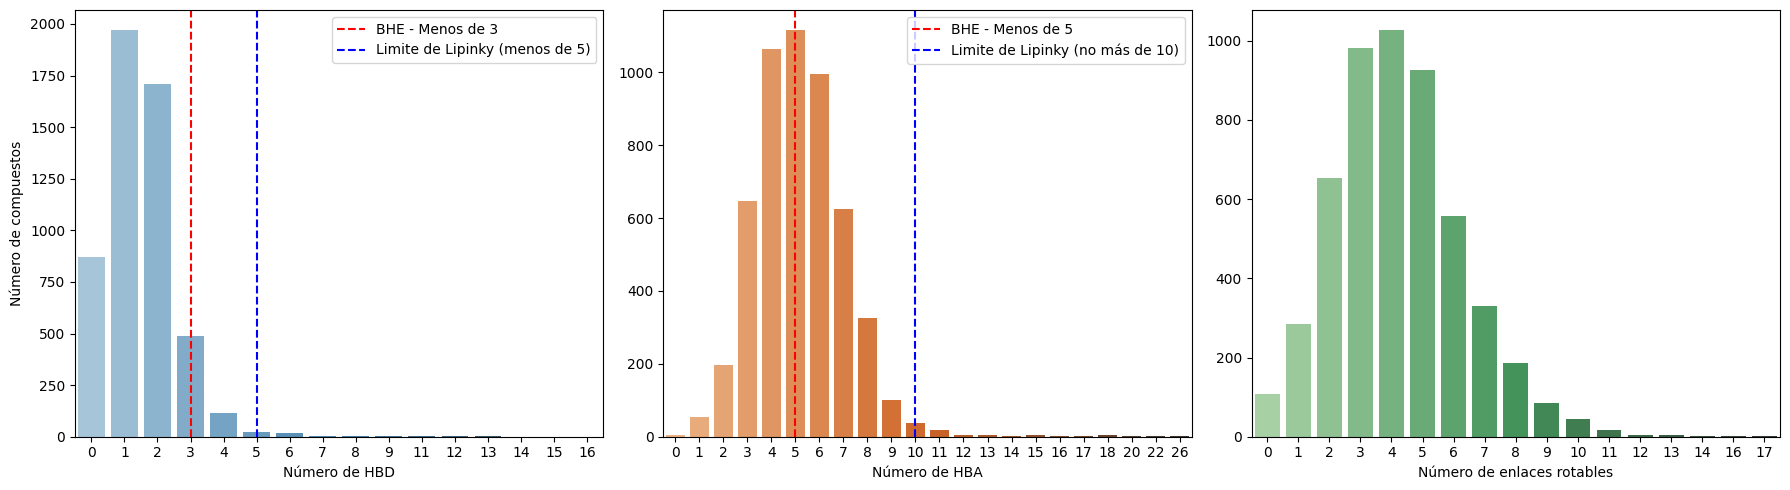

In [6]:
#Graficos para descriptores fisicoquimicos discretos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Dondadores de Enlace de puente de hidrógeno
sns.countplot(data=database, x="NumHBD", ax=axes[0], palette="Blues_d")
#axes[0].set_title("Distribución del número de átomos donadores de puente de hidrógeno")
axes[0].axvline(3, color="red", linestyle="--", label="BHE - Menos de 3")
axes[0].axvline(5, color="blue", linestyle="--", label="Limite de Lipinky (menos de 5)")
axes[0].set_xlabel("Número de HBD")
axes[0].set_ylabel("Número de compuestos")
axes[0].legend()

# Gráfico 2: Aceptores de Enlace de Hidrógeno
sns.countplot(data=database, x="NumHBA", ax=axes[1], palette="Creams_d" if "Creams_d" in dir(sns.color_palette) else "Oranges_d")
axes[1].axvline(5, color="red", linestyle="--", label="BHE - Menos de 5")
axes[1].axvline(10, color="blue", linestyle="--", label="Limite de Lipinky (no más de 10)")
#axes[1].set_title("Distribución del número de átomos aceptores de puente de hidrógeno")
axes[1].set_xlabel("Número de HBA")
axes[1].set_ylabel("")
axes[1].legend()

# Gráfico 3: Enlaces Rotables
sns.countplot(data=database, x="NumRotatableBonds", ax=axes[2], palette="Greens_d")
#axes[2].set_title("Distribución del número de enlaces rotables")
axes[2].set_xlabel("Número de enlaces rotables")
axes[2].set_ylabel("")


plt.tight_layout()
plt.show()


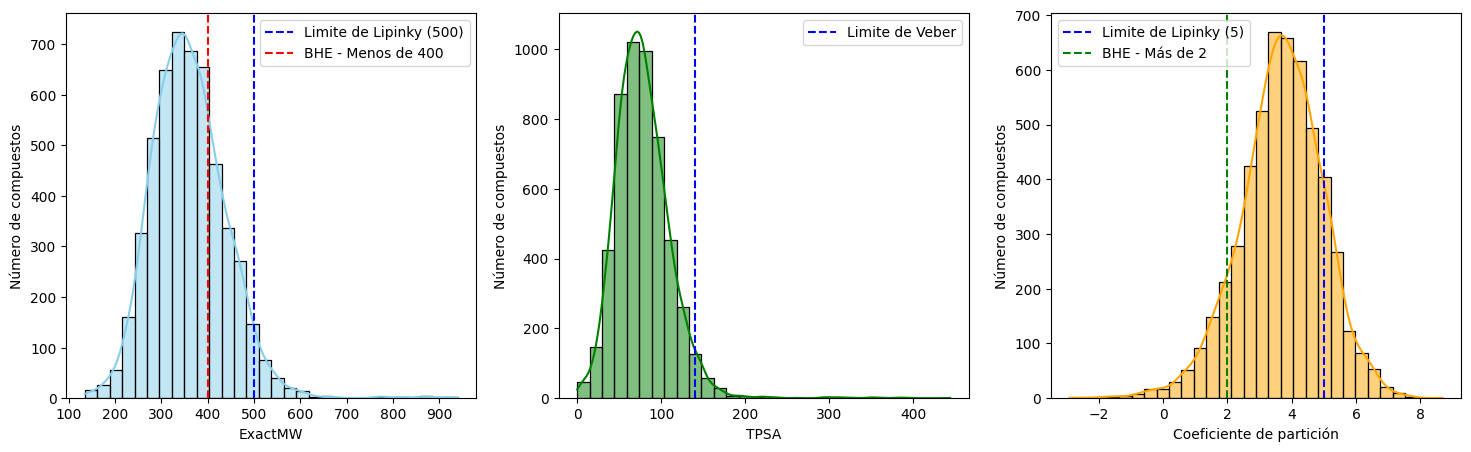

In [7]:
#Graficos para descriptores fisicoquimicos con valores continuos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=database, x="ExactMW", kde=True, ax=axes[0], color="skyblue", bins=30)

axes[0].axvline(500, color="blue", linestyle="--", label="Limite de Lipinky (500)")
axes[0].axvline(400, color="red", linestyle="--", label="BHE - Menos de 400")
#axes[0].set_title("Distribution of Molecular Weight")
axes[1].set_xlabel("Peso molar")
axes[0].set_ylabel("Número de compuestos")
axes[0].legend()

sns.histplot(data=database, x="TPSA", kde=True, ax=axes[1], color="green", bins=30)
axes[1].axvline(140, color="blue", linestyle="--", label="Limite de Veber")
axes[1].set_xlabel("TPSA")
axes[1].set_ylabel("Número de compuestos")
axes[1].legend()

sns.histplot(data=database, x="SlogP", kde=True, ax=axes[2], color="orange", bins=30)
axes[2].axvline(5, color="blue", linestyle="--", label="Limite de Lipinky (5)")
axes[2].axvline(2, color="green", linestyle="--", label="BHE - Más de 2")
axes[2].set_xlabel("Coeficiente de partición")
axes[2].set_ylabel("Número de compuestos")
axes[2].legend(loc='upper left')


plt.show()

In [8]:
#Analisis estadistico
columnas_descr = ["ExactMW", "SlogP", "TPSA", "NumHBA", "NumHBD", "NumRotatableBonds"]

estaditica_desc = database[columnas_descr].describe()
print(estaditica_desc)

           ExactMW        SlogP         TPSA       NumHBA       NumHBD  \
count  5211.000000  5211.000000  5211.000000  5211.000000  5211.000000   
mean    360.712313     3.680351    78.474040     5.194588     1.484552   
std      81.718301     1.304624    33.597095     1.924820     1.162061   
min     135.035400    -2.915200     0.000000     0.000000     0.000000   
25%     305.072179     2.902000    56.455000     4.000000     1.000000   
50%     354.121572     3.729300    75.270000     5.000000     1.000000   
75%     409.144327     4.534110    96.440000     6.000000     2.000000   
max     940.118181     8.692200   444.180000    26.000000    16.000000   

       NumRotatableBonds  
count        5211.000000  
mean            4.218192  
std             2.080386  
min             0.000000  
25%             3.000000  
50%             4.000000  
75%             5.000000  
max            17.000000  


# Compuestos más potentes



In [9]:
print(database.columns[:50])

Index(['Molecule ChEMBL ID', 'Molecule Name', 'Smiles', 'Standard Type',
       'Standard Relation', 'Standard Value', 'Standard Units', 'Comment',
       'Molecule Max Phase', 'Activity µM', 'canonical_smiles', 'NEW_SMILES',
       'SMILES_new', 'SlogP', 'TPSA', 'ExactMW', 'NumRotatableBonds', 'NumHBD',
       'NumHBA'],
      dtype='object')


In [10]:
#Analisis de top compuestos más potentes. Obtención de estructuras.
"""Los valores de potencia estan en la columna de Stanndar value y sus Unidades en Standar Units
Todos los compuestos están en nM"""
print(database["Standard Value"][:5])
print(database["Standard Units"][:5])


0    100.0
1    125.9
2    190.0
3    316.2
4    398.1
Name: Standard Value, dtype: float64
0    nM
1    nM
2    nM
3    nM
4    nM
Name: Standard Units, dtype: object


In [11]:
#Revisar que database solo tiene compuestos activos.
print(database["Comment"].unique())

['Active']


In [12]:
database_potency = database.sort_values(by="Standard Value")
database_potency["Potency[μM]"] = (database_potency['Standard Value'] / 1000).round(7)


In [13]:
print(database_potency["Standard Value"][:20])

0     100.0
1     125.9
2     190.0
3     316.2
4     398.1
5     446.7
6     446.7
7     501.2
11    501.2
10    501.2
8     501.2
9     501.2
12    501.2
13    562.3
15    562.3
14    562.3
19    631.0
17    631.0
18    631.0
16    631.0
Name: Standard Value, dtype: float64


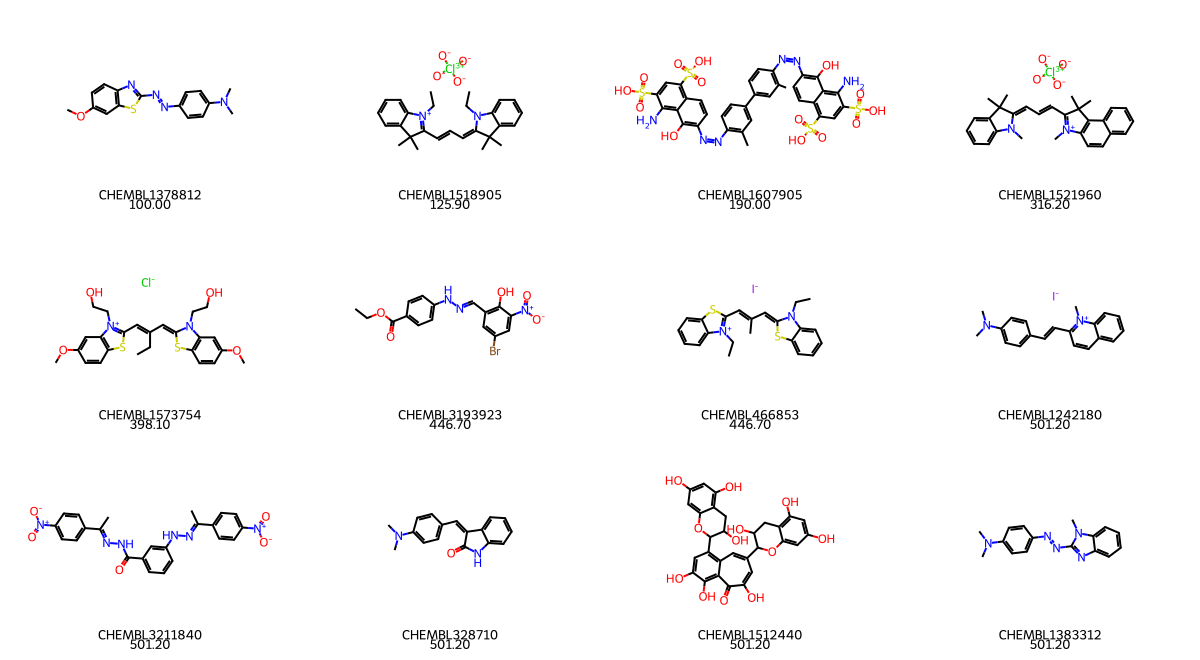

In [14]:
#Top 12 most potent compounds
#activity en nM
top_12 = database_potency.head(12)

mols = [Chem.MolFromSmiles(s) for s in top_12["Smiles"]]

leyendas = [
    f"{row['Molecule ChEMBL ID']}\n{row['Standard Value']:.2f}"
    for _, row in top_12.iterrows()
]

drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 20
drawer_options.baseFontSize = 1.2


img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 220),
    legends=leyendas,
    drawOptions=drawer_options
)

img

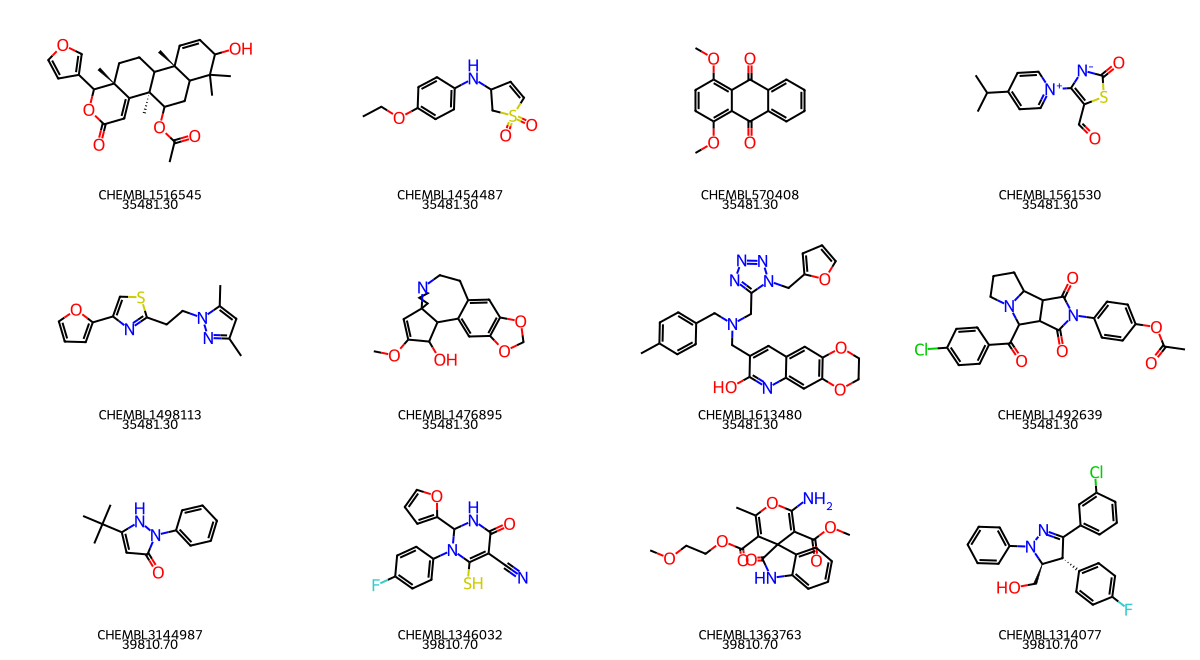

In [15]:
#Top 12 less potent compounds
#Potency in nM
top_12_l = database_potency.tail(12)

mols = [Chem.MolFromSmiles(s) for s in top_12_l["Smiles"]]

leyendas = [
    f"{row['Molecule ChEMBL ID']}\n{row['Standard Value']:.2f}"
    for _, row in top_12_l.iterrows()
]

drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 20
drawer_options.baseFontSize = 1.2


img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 220),
    legends=leyendas,
    drawOptions=drawer_options
)

img

# Núcleos estructurales

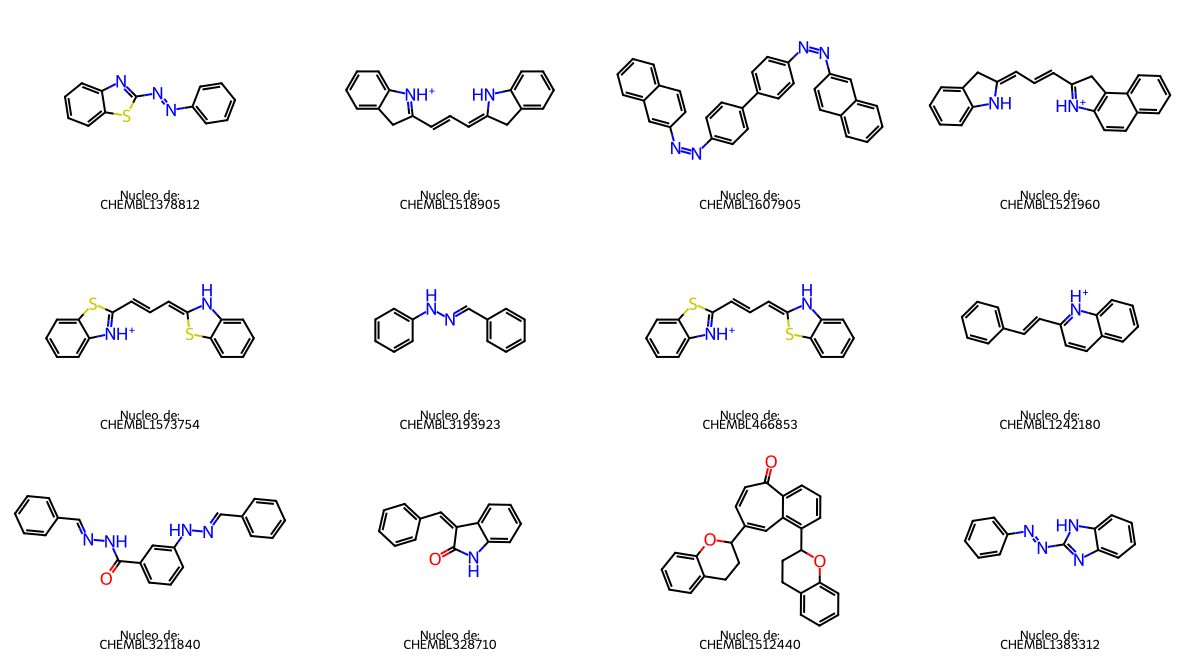

In [16]:
#Generar scaffolds
database_potency["mols"] = [Chem.MolFromSmiles(smile) for smile in database_potency["Smiles"]]
database_potency["scaffolds"] = [GetScaffoldForMol(mol) for mol in database_potency["mols"]]

top_12_scaffolds = database_potency.head(12)

mols_a_dibujar = top_12_scaffolds["scaffolds"].tolist()

leyendas = [
    f"Nucleo de:\n{row['Molecule ChEMBL ID']}"
    for _, row in top_12_scaffolds.iterrows()
]

drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 20
drawer_options.baseFontSize = 1.2


sca = Draw.MolsToGridImage(
    mols_a_dibujar,
    molsPerRow=4,
    subImgSize=(300, 220),
    legends=leyendas,
    drawOptions=drawer_options
)

sca



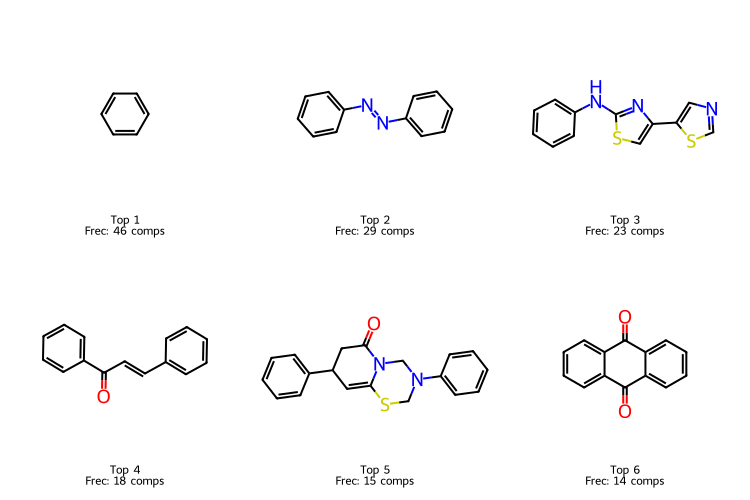

In [19]:
database_potency["scaffolds_smiles"] = [
    Chem.MolToSmiles(scaffold, canonical=True) if scaffold is not None else None
    for scaffold in database_potency["scaffolds"]
]

#Agrupar y contar frecuencias
scaffolds_counts = database_potency["scaffolds_smiles"].value_counts().reset_index()
scaffolds_counts.columns = ["Scaffold SMILES", "Frecuencia"]

top_6_scaffolds = scaffolds_counts.head(6)

scaffolds_a_dibujar = [Chem.MolFromSmiles(s) for s in top_6_scaffolds["Scaffold SMILES"]]

leyendas = [
    f"Top {i+1}\nFrec: {row['Frecuencia']} comps"
    for i, row in top_6_scaffolds.iterrows()
]

drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 16
drawer_options.baseFontSize = 1.2
drawer_options.bondLineWidth = 2

top = Draw.MolsToGridImage(
    scaffolds_a_dibujar,
    molsPerRow=3,
    subImgSize=(250, 250),
    legends=leyendas,
    drawOptions=drawer_options
)

top


# LiPE plots


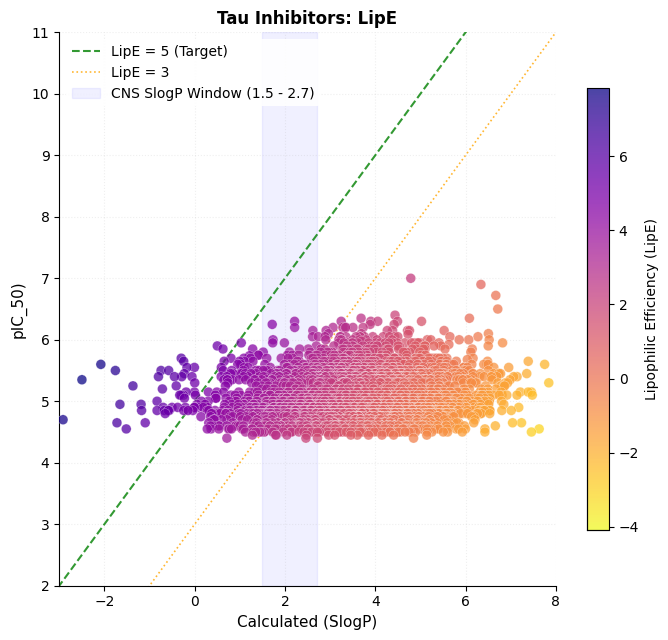

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

database_potency["pIC50"] = 9 - np.log10(database["Standard Value"])

database_potency["LipE"] = database_potency["pIC50"] - database_potency["SlogP"]

plt.figure(figsize=(7, 6.5))

sc = plt.scatter(
    database_potency["SlogP"],
    database_potency["pIC50"],
    c=database_potency["LipE"],
    cmap="plasma_r",
    alpha=0.75,
    edgecolors="w",
    linewidths=0.25,
    s=50,
    zorder=3
)

x_vals = np.linspace(-4, 9, 100)
plt.plot(x_vals, x_vals + 5, color="green", linestyle="--", linewidth=1.5, alpha=0.8, label="LipE = 5 (Target)", zorder=2)
plt.plot(x_vals, x_vals + 3, color="orange", linestyle=":", linewidth=1.2, alpha=0.8, label="LipE = 3", zorder=2)

plt.axvspan(1.5, 2.7, color="blue", alpha=0.06, label="CNS SlogP Window (1.5 - 2.7)", zorder=1)

plt.colorbar(sc, label="Lipophilic Efficiency (LipE)", shrink=0.8)
plt.xlim(-3, 8)
plt.ylim(2, 11)

plt.xlabel("Calculated (SlogP)", fontsize=11)
plt.ylabel("pIC_50)", fontsize=11)
plt.title("Tau Inhibitors: LipE", fontsize=12, fontweight="bold")
plt.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.9
)
plt.grid(alpha=0.2, linestyle=":")

sns.despine()
plt.tight_layout()
plt.show()

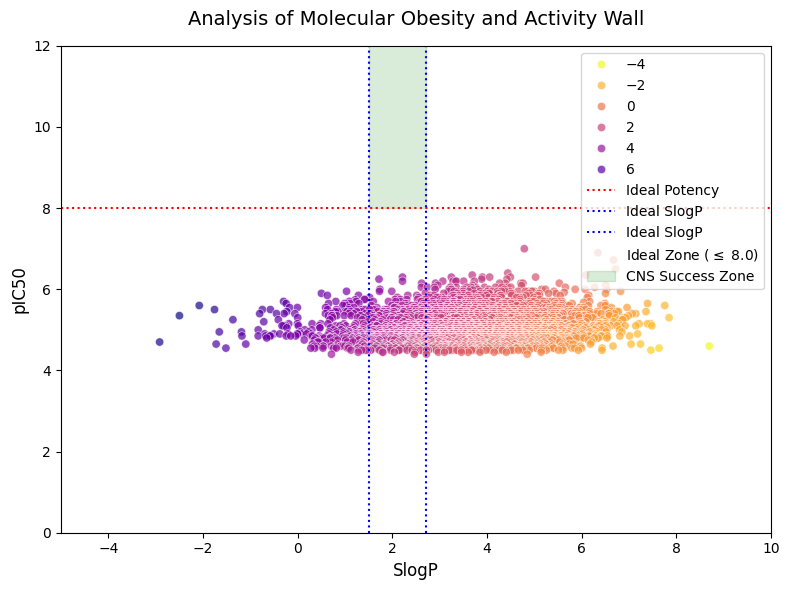

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))


sns.scatterplot(
    data=database_potency,
    x="SlogP",
    y="pIC50",
    hue="LipE",
    palette="plasma_r",
    alpha=0.7,
)


plt.xlabel("SlogP", fontsize=12)
plt.ylabel("pIC50", fontsize=12)
plt.ylim(0, 12)
plt.xlim(-5, 10)

plt.axhline(y=8, color="red", linestyle=":", linewidth=1.5, label="Ideal Potency")
plt.axvline(x=1.5, color="blue", linestyle=":", linewidth=1.5, label="Ideal SlogP")
plt.axvline(x=2.7, color="blue", linestyle=":", linewidth=1.5, label="Ideal SlogP")

x_arrows = np.arange(-15, 11, 3)
y_arrows = np.full_like(x_arrows, 8)

# Zona de éxito: SlogP <= 2 y pIC50 >= 8
# Ajustamos el límite inferior de x a -15 para que coincida exactamente con tu xlim
plt.plot(
    x_arrows,
    y_arrows,
    color="red",
    linestyle="None",
    markersize=7,
    label=r"Ideal Zone ($\leq$ 8.0)",
)

plt.fill_between(
    x=[1.5, 2.7],
    y1=8,
    y2=20,
    color="green",
    alpha=0.15,
    label="CNS Success Zone",
)

# Configuración de la leyenda para que no se duplique y muestre las etiquetas correctas
plt.legend(loc="upper right")
plt.title(
    "Analysis of Molecular Obesity and Activity Wall",
    fontsize=14,
    pad=15,
)
plt.tight_layout()

plt.show()

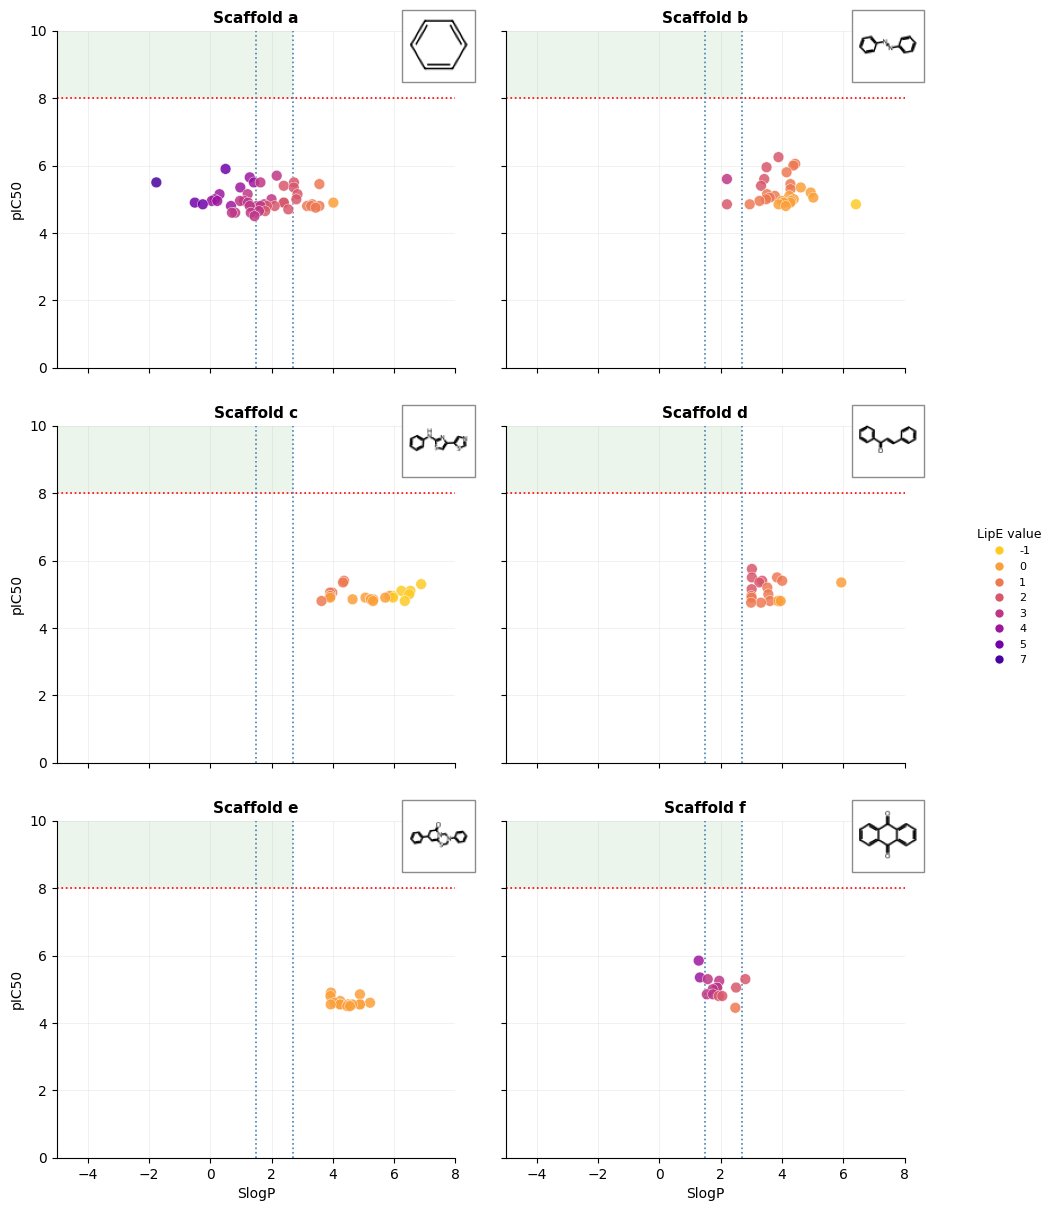

In [26]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import Rectangle
import seaborn as sns
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib.lines import Line2D


database_potency["pIC50"] = 9 - np.log10(database_potency["Standard Value"])

database_potency["Document Year"] = pd.to_numeric(
    database_potency["LipE"],
    errors="coerce"
)

top_6_smiles = scaffolds_counts.head(6)["Scaffold SMILES"].tolist()

df_top6 = database_potency[
    (database_potency["scaffolds_smiles"].isin(top_6_smiles)) &
    (database_potency["Document Year"].notna())
].copy()


years = sorted(df_top6["LipE"].dropna().astype(int).unique())

palette = sns.color_palette(
    "plasma_r",
    n_colors=len(years)
)

year_to_color = dict(zip(years, palette))

g = sns.FacetGrid(
    data=df_top6,
    col="scaffolds_smiles",
    col_order=top_6_smiles,
    col_wrap=2,
    height=4,
    aspect=1.3,
    sharex=True,
    sharey=True
)



drawer_options = Draw.MolDrawOptions()
drawer_options.clearBackground = True
drawer_options.bondLineWidth = 1.5
drawer_options.updateAtomPalette(
    {i:(0,0,0) for i in range(100)}
)


xmin = -5
xmax = 8

ymin = 0
ymax = 10

letters = ["a","b","c","d","e","f"]


for i,(smiles,ax) in enumerate(zip(top_6_smiles,g.axes.flat)):

    subset = df_top6[
        df_top6["scaffolds_smiles"]==smiles
    ]

    sc = ax.scatter(
      subset["SlogP"],
      subset["pIC50"],
      c=[year_to_color[int(y)] for y in subset["LipE"]],
      s=60,
      edgecolor="white",
      linewidth=0.35,
      alpha=0.85,
      zorder=3
      )

    rect = Rectangle(
          (-5, 8),
          7.7,
          4,
          facecolor="green",
          alpha=0.08,
          linewidth=0,
          zorder=0
      )

    ax.add_patch(rect)


    ax.axhline(
        8,
        color="red",
        ls=":",
        lw=1.2
    )

    ax.axvline(
        1.5,
        color="steelblue",
        ls=":",
        lw=1.2
    )

    ax.axvline(
        2.7,
        color="steelblue",
        ls=":",
        lw=1.2
    )



    ax.set_xlim(xmin,xmax)
    ax.set_ylim(ymin,ymax)



    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:

        img = Draw.MolToImage(
            mol,
            size=(55,55),
            options=drawer_options
        )

        imagebox = OffsetImage(
            img,
            zoom=0.80
        )

        ab = AnnotationBbox(
            imagebox,
            (xmax-0.55,ymax-0.45),
            frameon=True,
            bboxprops=dict(
                facecolor="white",
                edgecolor="gray",
                alpha=0.90
            )
        )

        ax.add_artist(ab)


    ax.set_title(
        f"Scaffold {letters[i]}",
        fontsize=11,
        weight="bold"
    )

    ax.grid(
        alpha=0.25,
        linewidth=0.5
    )

    sns.despine(ax=ax)


g.set_axis_labels(
    "SlogP",
    "pIC50"
)



legend_elements = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=year_to_color[y],
        markersize=7,
        label=str(y)
    )
    for y in years
]

g.figure.legend(
    handles=legend_elements,
    title="LipE value",
    loc="center left",
    bbox_to_anchor=(0.92,0.5),
    frameon=False,
    fontsize=8,
    title_fontsize=9
)

plt.subplots_adjust(
    right=0.86
)

plt.show()


In [27]:
import pandas as pd
from rdkit import Chem

# 1. Obtener la lista de los 6 scaffolds más frecuentes
top_6_smiles = scaffolds_counts.head(6)["Scaffold SMILES"].tolist()

# 2. Filtrar el DataFrame para quedarnos únicamente con los compuestos del Top 6
df_resumen = database_potency[database_potency["scaffolds_smiles"].isin(top_6_smiles)].copy()

# 3. Construir la tabla agrupando y contando usando agregación nombrada
tabla_scaffolds = (
    df_resumen.groupby("scaffolds_smiles")
    .agg(Num_Compuestos=("scaffolds_smiles", "count"))
    .reset_index()
)

# 4. Ordenar la tabla para que coincida exactamente con el orden jerárquico del Top 6
tabla_scaffolds["scaffolds_smiles"] = pd.Categorical(
    tabla_scaffolds["scaffolds_smiles"],
    categories=top_6_smiles,
    ordered=True
)
tabla_scaffolds = tabla_scaffolds.sort_values("scaffolds_smiles").reset_index(drop=True)

# 5. Insertar la columna de Ranking al inicio
tabla_scaffolds.insert(0, "Ranking", [f"Top {i+1}" for i in range(len(tabla_scaffolds))])

# Visualizar la tabla en el Notebook
display(tabla_scaffolds)

,Ranking,scaffolds_smiles,Num_Compuestos
0,Top 1,c1ccccc1,46
1,Top 2,c1ccc(N=Nc2ccccc2)cc1,29
2,Top 3,c1ccc(Nc2nc(-c3cncs3)cs2)cc1,23
3,Top 4,O=C(/C=C/c1ccccc1)c1ccccc1,18
4,Top 5,O=C1CC(c2ccccc2)C=C2SCN(c3ccccc3)CN12,15
5,Top 6,O=C1c2ccccc2C(=O)c2ccccc21,14


In [28]:
import pandas as pd

# 1. Asegurar que tenemos calculado el LipE en el DataFrame general
df_top6["LipE"] = df_top6["pIC50"] - df_top6["SlogP"]

# 2. Agrupar por scaffold calculando promedios, máximos y desviaciones estándar
summary_metrics = (
    df_top6.groupby("scaffolds_smiles")
    .agg(
        Frecuencia=("scaffolds_smiles", "count"),
        pIC50_Max=("pIC50", "max"),
        pIC50_Promedio=("pIC50", "mean"),
        pIC50_SD=("pIC50", "std"),  # <--- Desviación Estándar de pIC50
        SlogP_Promedio=("SlogP", "mean"),
        SlogP_SD=("SlogP", "std"),  # <--- Desviación Estándar de SlogP
        LipE_Max=("LipE", "max"),
        LipE_Promedio=("LipE", "mean"),
        LipE_SD=("LipE", "std"),  # <--- Desviación Estándar de LipE
        # Identificar qué molécula específica es la mejor en eficiencia lipofílica
        Best_Molecule_ID=(
            "Molecule ChEMBL ID",
            lambda x: df_top6.loc[x.index]
            .sort_values(by="LipE", ascending=False)["Molecule ChEMBL ID"]
            .iloc[0],
        ),
    )
    .reset_index()
)

# 3. Ordenar la tabla por frecuencia (de mayor a menor)
summary_metrics = summary_metrics.sort_values(by="Frecuencia", ascending=False).reset_index(drop=True)

# 4. Formatear los decimales para estilo de publicación científica
pd.options.display.float_format = "{:,.2f}".format

# 5. Desplegar la tabla con las nuevas columnas estadísticas
print("=== TABLA RESUMEN DE EFICIENCIA POR SCAFFOLD (CON SD) ===")
print(
    summary_metrics[
        [
            "Frecuencia",
            "pIC50_Max",
            "pIC50_Promedio",
            "pIC50_SD",
            "SlogP_Promedio",
            "SlogP_SD",
            "LipE_Max",
            "LipE_Promedio",
            "LipE_SD",
            "Best_Molecule_ID",
        ]
    ]
)

=== TABLA RESUMEN DE EFICIENCIA POR SCAFFOLD (CON SD) ===
   Frecuencia  pIC50_Max  pIC50_Promedio  pIC50_SD  SlogP_Promedio  SlogP_SD  \
0          46       5.90            5.01      0.33            1.66      1.22   
1          29       6.25            5.25      0.42            3.96      0.82   
2          23       5.40            4.98      0.17            5.16      1.02   
3          18       5.75            5.12      0.32            3.56      0.70   
4          15       4.90            4.62      0.13            4.44      0.40   
5          14       5.85            5.07      0.33            1.91      0.44   

   LipE_Max  LipE_Promedio  LipE_SD Best_Molecule_ID  
0      7.26           3.34     1.29    CHEMBL1255778  
1      3.39           1.29     0.94    CHEMBL1417630  
2      1.17          -0.18     1.03    CHEMBL1386092  
3      2.73           1.56     0.75    CHEMBL1456767  
4      0.96           0.18     0.45    CHEMBL1328519  
5      4.57           3.16     0.66      CHEMBL2989

Analisis y filtro de compuestos con buen perfil LipE. Si tienen buen valor de lipofilidad y son muy activos, ¿Por qué no se han seguido estudiando/ porqué no estan en el mercado?

Posible respuesta:
-Generan efectos adversos por presencia de toxicoforos
-Tienen estructuras tipo PAINS




In [29]:
#Identificación de los compuestos con un perfil adecuado: Actividad pIC50 mayor a 8, sLogp 1.5 a 2.7
#Pero tambien otras propiedades fisicoquimicas ideales para permear


database_potency_1 = database_potency.copy()

#Definir las condiciones utilizando el dataframe de entrada

cond_pIC50 = database_potency_1["pIC50"] >= 8.0
cond_slogp = (database_potency_1["SlogP"] >= 1.5) & (database_potency_1["SlogP"] <= 2.7)
#cond_mw = df_resultado["ExactMW"] <= 500
#cond_hba = df_resultado["NumHBA"] <= 6
#cond_hbd = df_resultado["NumHBD"] <= 3
#cond_tpsa = df_resultado["TPSA"] <= 90

#Combinar todas las reglas en un filtro lógico (solo lipE + sLogP)
filtro_ideal = cond_pIC50 & cond_slogp

#Combinar todas las reglas en un filtro lógico (para permeabilidad de BBB)
#filtro_ideal = cond_pIC50 & cond_slogp & cond_mw & cond_hba & cond_hbd & cond_tpsa

#Asignar la etiqueta en una nueva columna ("Sí" si cumple todas, "No" si falla al menos una)
database_potency_1["Ideal_Perfil"] = "No"
database_potency_1.loc[filtro_ideal, "Ideal_Perfil"] = "Sí"

#Reporte estadístico sin recortar el dataset
total_compuestos = len(database_potency_1)
total_ideales = filtro_ideal.sum()
total_no_ideales = total_compuestos - total_ideales

print(f"Total de compuestos en el dataset: {total_compuestos}")
print(f"Total de compuestos ideales: {total_ideales} (equivalente al {((total_ideales / total_compuestos) * 100):.2f}%)")
print(f"Total de compuestos no ideales: {total_no_ideales} (equivalente al {((total_no_ideales / total_compuestos) * 100):.2f}%)")

BACE1_ideal = database_potency_1[database_potency_1["Ideal_Perfil"] == "Sí"].copy()


Total de compuestos en el dataset: 5211
Total de compuestos ideales: 0 (equivalente al 0.00%)
Total de compuestos no ideales: 5211 (equivalente al 100.00%)


# Toxicoforos en BACE1 ideal


In [50]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import FilterCatalog


def etiquetar_toxicoforos_brenk(
    database_potency_1, columna_smiles="Smiles", archivo_salida="ideal_brenk.csv"
):
    """Evalúa la presencia de toxicóforos o alertas estructurales (reglas de

    Brenk et al.) en el dataset 'BACE1_ideal'. Añade columnas nominales sin
    eliminar compuestos y exporta el resultado final a un archivo CSV.
    """

    # 1. Configurar el catálogo explícitamente para BRENK
    params = FilterCatalog.FilterCatalogParams()
    params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
    catalogo_brenk = FilterCatalog.FilterCatalog(params)

    es_toxicoforo_nominal = []
    motivo_toxicoforo = []

    print("Iniciando análisis estructural de la quimioteca...")

    # 2. Análisis molecular ciclo por ciclo
    for s in database_potency_1[columna_smiles]:
        mol = Chem.MolFromSmiles(s)

        if mol is None:
            es_toxicoforo_nominal.append("Sí")
            motivo_toxicoforo.append("SMILES Inválido")
            continue

        # Verificar si hace match con alguna alerta estructural de Brenk
        if catalogo_brenk.HasMatch(mol):
            es_toxicoforo_nominal.append("Sí")
            match = catalogo_brenk.GetFirstMatch(mol)
            motivo_toxicoforo.append(match.GetDescription())
        else:
            es_toxicoforo_nominal.append("No")
            motivo_toxicoforo.append("Limpio")

    # 3. Añadir las columnas de diagnóstico a una copia del dataset original para no alterarlo
    ideal_brenk = database_potency_1.copy()
    ideal_brenk["Tiene_Toxicoforo"] = es_toxicoforo_nominal
    ideal_brenk["Motivo_Toxicoforo"] = motivo_toxicoforo

    # 4. Reporte estadístico global
    total_evaluadas = len(ideal_brenk)
    total_toxicos = es_toxicoforo_nominal.count("Sí")
    total_limpios = es_toxicoforo_nominal.count("No")

    # CORRECCIÓN: Control de división por cero
    if total_evaluadas > 0:
        porcentaje_toxicos = (total_toxicos / total_evaluadas) * 100
        porcentaje_limpios = (total_limpios / total_evaluadas) * 100
    else:
        porcentaje_toxicos = 0.00
        porcentaje_limpios = 0.00

    print("-" * 50)
    print("REPORTE GLOBAL DE TOXICÓFOROS (REGLAS BRENK)")
    print("-" * 50)
    print(f"Total de moléculas evaluadas en BACE1_ideal: {total_evaluadas}")
    print(
        f"Compuestos con toxicóforos / alertas estructurales: {total_toxicos} ({porcentaje_toxicos:.2f} %)"
    )
    print(
        f"Compuestos limpios (Estructuralmente seguros): {total_limpios} ({porcentaje_limpios:.2f} %)"
    )
    print("-" * 50)

    # 5. Exportar el dataset completo con sus nuevas columnas nominales a CSV
    ideal_brenk.to_csv(archivo_salida, index=False)
    print(
        f"¡Éxito! Dataset global guardado correctamente en: '{archivo_salida}'"
    )
    print("=" * 50)

    return ideal_brenk

ideal_brenk = etiquetar_toxicoforos_brenk(
    database_potency_1,
    columna_smiles="Smiles",
    archivo_salida="ideal_brenk.csv"
)

Iniciando análisis estructural de la quimioteca...
--------------------------------------------------
REPORTE GLOBAL DE TOXICÓFOROS (REGLAS BRENK)
--------------------------------------------------
Total de moléculas evaluadas en BACE1_ideal: 5211
Compuestos con toxicóforos / alertas estructurales: 3586 (68.82 %)
Compuestos limpios (Estructuralmente seguros): 1625 (31.18 %)
--------------------------------------------------
¡Éxito! Dataset global guardado correctamente en: 'ideal_brenk.csv'


# Estructuras de tipo brenk más freuentes en el archivo

In [54]:
import pandas as pd

Toxicoforos = ideal_brenk[ideal_brenk["Tiene_Toxicoforo"] == "Sí"].copy()


if len(Toxicoforos) > 0:
    tabla_toxicoforos = (
        Toxicoforos["Motivo_Toxicoforo"]
        .value_counts()
        .head(10)
        .reset_index()
    )

    tabla_toxicoforos.columns = ["Alerta Estructural (Brenk)", "Frecuencia"]

    tabla_toxicoforos["Porcentaje (%)"] = (tabla_toxicoforos["Frecuencia"] / len(Toxicoforos)) * 100

    print(f"📊 Mostrando el Top 10 de alertas estructurales más frecuentes (de un total de {len(Toxicoforos)} compuestos con alertas):")
    display(tabla_toxicoforos)
else:
    print("✨ Quimioteca libre de alertas: No hay toxicóforos que listar.")

📊 Mostrando el Top 10 de alertas estructurales más frecuentes (de un total de 3586 compuestos con alertas):


,Alerta Estructural (Brenk),Frecuencia,Porcentaje (%)
0,imine_1,913,25.46
1,Michael_acceptor_1,697,19.44
2,nitro_group,362,10.09
3,diazo_group,272,7.59
4,Aliphatic_long_chain,157,4.38
5,catechol,154,4.29
6,aniline,105,2.93
7,conjugated_nitrile_group,100,2.79
8,isolated_alkene,77,2.15
9,beta-keto/anhydride,75,2.09


# PAINS
 Identificación de PAINS en los ideales de BACE1

In [55]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import FilterCatalog


def eliminar_pains(df_entrada, columna_smiles="Smiles"):
    """Identifica y elimina moléculas que contienen subestructuras PAINS

    utilizando los catálogos oficiales de RDKit (Familia PAINS_A).
    """
    # Usando el catálogo PAINS_A
    params = FilterCatalog.FilterCatalogParams()
    params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_A)
    catalogo_pains = FilterCatalog.FilterCatalog(params)

    # Listas para almacenar los resultados del escaneo
    es_pains = []
    motivo_pains = []

    # Loop para evaluar cada SMILES
    for s in df_entrada[columna_smiles]:
        mol = Chem.MolFromSmiles(str(s))

        if mol is None:
            es_pains.append(True)
            motivo_pains.append("SMILES Inválido")
            continue

        # Verificar si la molécula hace match con algún filtro PAINS_A
        if catalogo_pains.HasMatch(mol):
            es_pains.append(True)
            match = catalogo_pains.GetFirstMatch(mol)
            motivo_pains.append(match.GetDescription())
        else:
            es_pains.append(False)
            motivo_pains.append("Limpio")

    # Crear el DataFrame de diagnóstico
    df_diagnostico = df_entrada.copy()
    df_diagnostico["Es_PAINS"] = es_pains
    df_diagnostico["Motivo_PAINS"] = motivo_pains

    # Filtrar para dejar solo las moléculas limpias (Es_PAINS == False)
    df_limpio = df_diagnostico[df_diagnostico["Es_PAINS"] == False].copy()

    total_inicial = len(df_entrada)
    total_final = len(df_limpio)
    pains_detectados = total_inicial - total_final

    # CORRECCIÓN: Control de división por cero
    if total_inicial > 0:
        porcentaje_pains = (pains_detectados / total_inicial) * 100
    else:
        porcentaje_pains = 0.00

    print("=" * 50)
    print("DETECCIÓN Y FILTRADO DE COMPUESTOS PAINS (FAMILIA A)")
    print("=" * 50)
    print(f"Moléculas iniciales: {total_inicial}")
    print(f"Moléculas limpias (sin PAINS): {total_final}")
    print(f"PAINS eliminados: {pains_detectados} ({porcentaje_pains:.2f}%)")
    print("=" * 50)

    # Retorna el dataframe estrictamente limpio y el de diagnóstico completo
    return df_limpio, df_diagnostico


# Llamada a la función
ideal_brenk_pains, ideal_pains_diagnostico = eliminar_pains(
    ideal_brenk, columna_smiles="Smiles"
)

DETECCIÓN Y FILTRADO DE COMPUESTOS PAINS (FAMILIA A)
Moléculas iniciales: 5211
Moléculas limpias (sin PAINS): 3884
PAINS eliminados: 1327 (25.47%)


# SAScore:
Los compuestos del dataset de BACE1 con mejor LipE exhibirán valores de SAScore elevados, lo que compromete su viabilidad sintética en el laboratorio. Esto representa una manifestación alternativa y ortogonal del 'Activity Wall'.


In [56]:
from rdkit import Chem  # CORRECCIÓN: Importación faltante para Chem.MolFromSmiles
from rdkit.Contrib.SA_Score import sascorer


# CORRECCIÓN DE IMPORTACIÓN: Configurar la ruta correcta al directorio 'Contrib' de RDKit


def calcular_sascore(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return sascorer.calculateScore(mol) if mol is not None else None
    except:
        return None


print("Calculando SA_Score para el dataset depurado...")

# 3. Aplicar el cálculo a la columna de SMILES
ideal_brenk_pains["SA_Score"] = ideal_brenk_pains["Smiles"].apply(
    calcular_sascore
)

# 4. Clasificar la viabilidad sintética usando una condición lógica
# Si SA_Score > 5 -> No Viable (difícil de sintetizar), de lo contrario -> Viable
ideal_brenk_pains["Viabilidad_Sintetica"] = ideal_brenk_pains[
    "SA_Score"
].apply(lambda x: "No Viable" if x > 5 else "Viable" if pd.notnull(x) else "Error")

# 5. Reporte estadístico rápido en consola
total = len(ideal_brenk_pains)
viables = (ideal_brenk_pains["Viabilidad_Sintetica"] == "Viable").sum()
no_viables = (
    ideal_brenk_pains["Viabilidad_Sintetica"] == "No Viable"
).sum()

print("=" * 50)
print("ANÁLISIS DE ACCESIBILIDAD SINTÉTICA (SA_SCORE)")
print("=" * 50)
print(f"Total de compuestos evaluados: {total}")
print(f"Compuestos Viables (SA <= 5): {viables} ({(viables/total)*100:.2f}%)")
print(
    f"Compuestos No Viables (SA > 5): {no_viables} ({(no_viables/total)*100:.2f}%)"
)
print("=" * 50)

# 6. Guardar el nuevo dataset con las métricas de síntesis añadidas
ideal_brenk_pains.to_csv("ideal_brenk_pains_sa.csv", index=False)
print("¡Dataset guardado exitosamente como 'ideal_brenk_pains_sa.csv'!")

Calculando SA_Score para el dataset depurado...
ANÁLISIS DE ACCESIBILIDAD SINTÉTICA (SA_SCORE)
Total de compuestos evaluados: 3884
Compuestos Viables (SA <= 5): 3857 (99.30%)
Compuestos No Viables (SA > 5): 27 (0.70%)
¡Dataset guardado exitosamente como 'ideal_brenk_pains_sa.csv'!
